На семинаре мы рассматривали постановку OCO (Online Convex Optimization) применительно к онлайн выбору портфеля акций. Мы рассмотрели простой алгоритм Follow The **Linearized** Leader + два алгоритма в стратегии Follow The **Regularized** Leader:  [Exponentiated Gradient](http://www.rob.schapire.net/papers/HelmboldScSiWa98.pdf) и  [AdaHedge](https://arxiv.org/pdf/1912.13213) (7.6), в которых в качестве регуляризатора выступала **энтропия Шеннона** : $R(x) = \sum_{j=1}^{n} x_j log(x_j)$


Но могут быть и другие регуляризаторы, которые порождают другие алгоритмы. Например, **log-barier**: $R(x) = \sum_{j=1}^{n} log(<x, e_j>)$, где $(e_i)_{i=1}^n$ - базис. И задача принимает вид: $$x_t = argmax _{x\in \Delta_n} \sum_{t+1}^{t-1} log(<r_t, x>) + \sum_{j=1}^{n} log(<x, e_j>)$$

Если выбор портфеля происходит по формуле выше, то такая стратегия назвается **Smooth Selection**.

Но если в лоб решать эту задачу (назовем алгоритм **ss**), то регрет будет содержать в себе $r$, где $r$ нижняя граница всех регретов, т.е мы подразумеваем, что:
$1\geq r_t[i]\geq r > 0$.

Чтобы оценка регрета не содержала $r$ можно предложить модификацию алгоритма (назовем  **modified_ss**) с заменой, как в семинаре:
$$\tilde{r}_t ← (1-\frac{\alpha}{n})r_t + \frac{\alpha}{n} 1$$

$$\tilde{x}_t = (1-\alpha)x_t + \frac{\alpha}{n}$$

Cобственно, эти два алгоритма (ss + modified_ss) нужно реализвовать, и проверить их работу на синтетических и реальных ланный с yahoo. Части, которые повторяются с семинара уже используются, но в ноутбук семинара полезно заглянуть, чтобы понять как реализвать функции.

In [1]:
import cvxpy as cp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf
import pandas as pd
import string
import random

sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (16, 8)

In [2]:
"""выбрать лучший портфель в терминах OCO 'заглядывая в будущее'

   с семинара - здесь ничего менять не нужно
"""


def Best_Constantly_Rebalanced_Portfolio(r):
    T = r.shape[0]
    n = r.shape[1]
    if T == 0:
        return np.ones(n) / n

    x = cp.Variable(n)

    obj = cp.sum(cp.log(r @ x))
    prob = cp.Problem(cp.Maximize(obj), [cp.sum(x) == 1, x >= 0])
    prob.solve()
    return x.value

$$x_t = argmax _{x\in \Delta_n} \sum_{t+1}^{t-1} log(<r_t, x>) + \sum_{j=1}^{n} log(<x, e_j>)$$

Smooth_Selection выдает вектор решений на каждом шаге, можете написать либо свою функцию. Либо интереснее подумать, как можно написать с помощью ранее определенной Best_Constantly_Rebalanced_Portfolio

In [3]:
# Smooth_Selection на вход принимает r - вектор регретов, выдает вектор портфеля x до рассматриваемого шага t
# можно и нужно использовать ранее определенную Best_Constantly_Rebalanced_Portfolio (посмотри в семинаре)
def Smooth_Selection(r):
    T = r.shape[0]
    n = r.shape[1]

    xs = np.zeros(shape=(T, n))
    xs[0] = np.ones(n) / n
    basis = np.eye(n)

    for t in range(1, T):
        x = cp.Variable(n)

        objective = cp.sum(cp.log(r[:t] @ x)) + cp.sum(cp.log(basis @ x))
        problem = cp.Problem(cp.Maximize(objective), [cp.sum(x) == 1, x >= 0])
        problem.solve()
        xs[t] = x.value

    return xs


с модификацией мы должны решать задачу:

$$ x_t = argmax_{x\in \Delta_n} \sum_{t+1}^{t-1} \log(<\tilde{r}_t, x>) + \varepsilon * \sum_{j=1}^{n} \log(<\tilde{x}, e_j>) $$ 
подставляя:

$$\tilde{r}_t ← (1-\frac{\alpha}{n})r_t + \frac{\alpha}{n} 1$$

$$\tilde{x}_t = (1-\alpha)x_t + \frac{\alpha}{n}$$

$$\varepsilon =  \frac{1}{r_{min}}$$
$$\alpha =  n \sqrt{\frac{\log T}{T}}$$


In [4]:
def Modified_Smooth_Selection(r):
    T = r.shape[0]
    n = r.shape[1]

    alpha = n * np.sqrt(np.log(T) / T)
    eps = 1 / np.min(r)

    if T == 0:
        return np.ones(n) / n

    xs = np.zeros(shape=(T, n))
    xs[0] = np.ones(n) / n

    r_tilde = (1 - alpha / n) * r + alpha / n
    basis = np.eye(n)

    for t in range(1, T):
        x = cp.Variable(n)
        x_tilde = (1 - alpha) * x + alpha / n
        objective = cp.sum(cp.log(r_tilde[:t] @ x)) + eps * cp.sum(
            cp.log(basis @ x_tilde)
        )
        problem = cp.Problem(cp.Maximize(objective), [cp.sum(x) == 1, x >= 0])
        problem.solve()

        xs[t] = (1 - alpha) * x.value + alpha / n

    return xs

ПРОВЕРКА РАБОТЫ НА СИНТЕТИКЕ

In [5]:
random.seed(444)
np.random.seed(444)
# число стоков(акций)
n = 5
# генерим названия стоков
dummy_stocks = ["".join(random.choices(string.ascii_uppercase, k=5)) for i in range(n)]
# рассматриваемый период
T = 700

# Log-normal returns
r = np.exp(np.random.normal(0, 0.03, size=(T, n)))
df = pd.DataFrame(data=r.cumprod(axis=0), columns=dummy_stocks)

<Axes: >

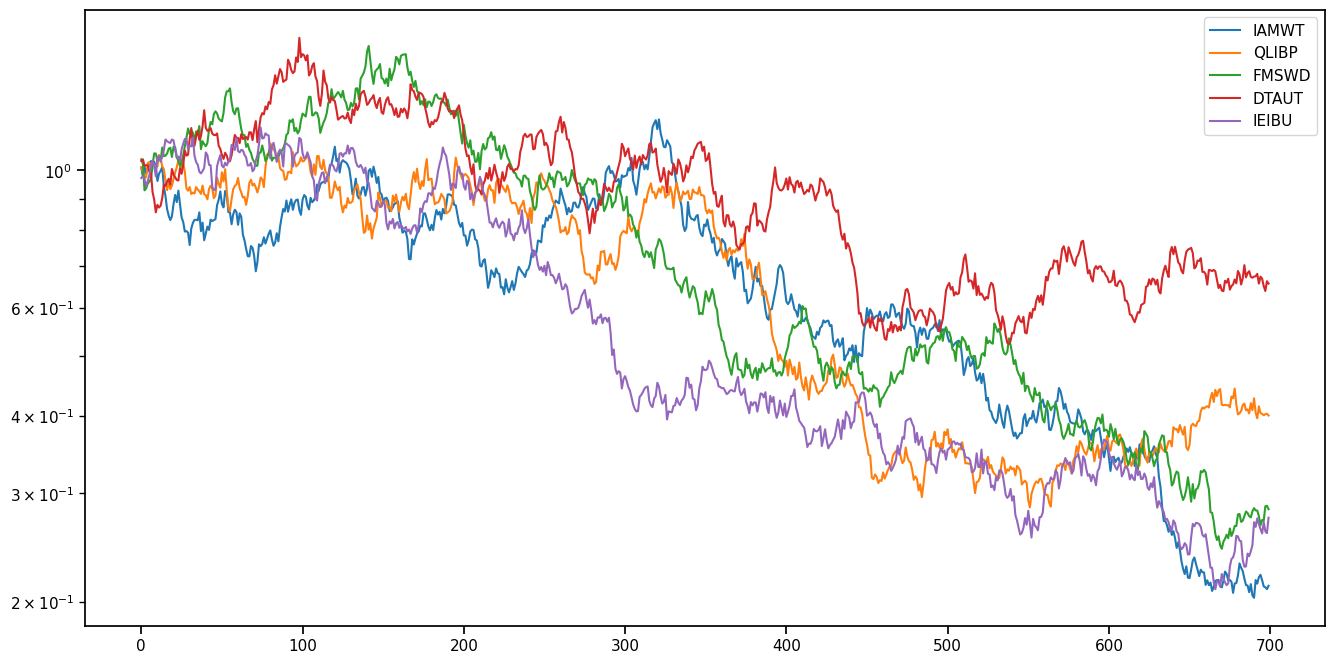

In [6]:
df.plot(logy=True)

In [7]:
ss = Smooth_Selection(r)
df["SS"] = np.cumprod(np.sum(r * ss, axis=1))

mss = Modified_Smooth_Selection(r)
df["MSS"] = np.cumprod(np.sum(r * mss, axis=1))

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)

/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Axes: >

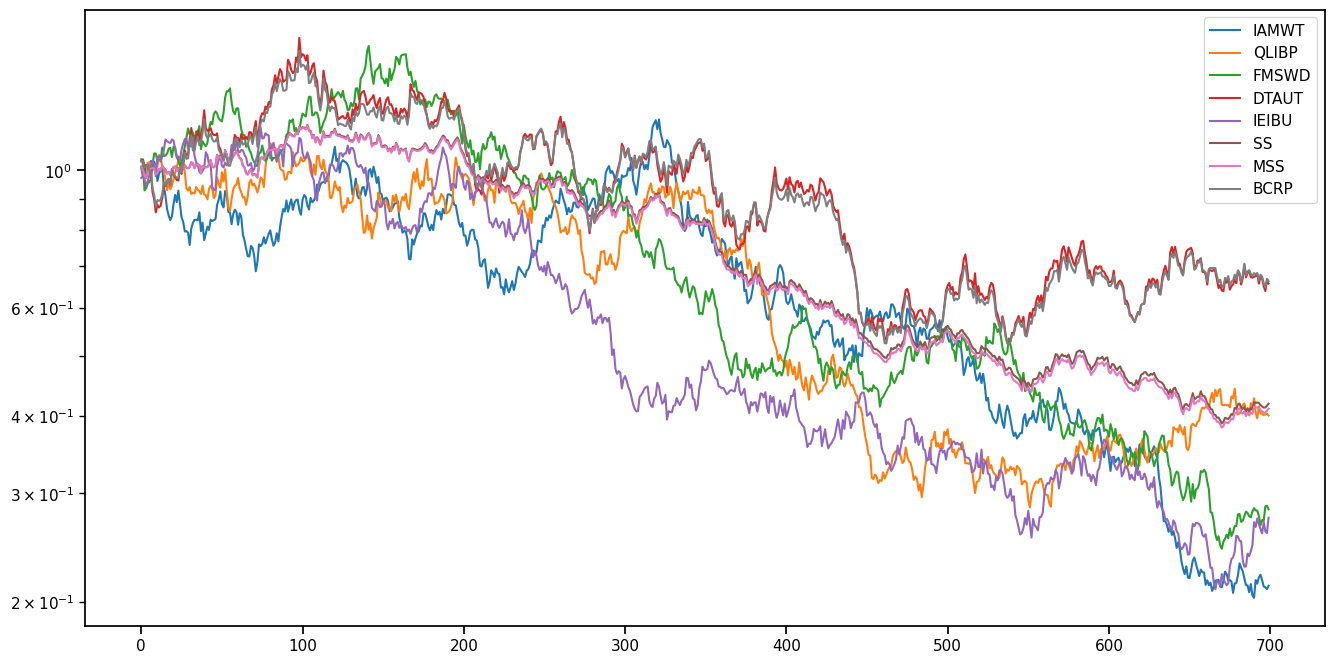

In [8]:
# cмотрим как ведут себя стратегии smooth и modified smooth по отношению к траекториям отдельных акций
df.plot(logy=True)

<Axes: >

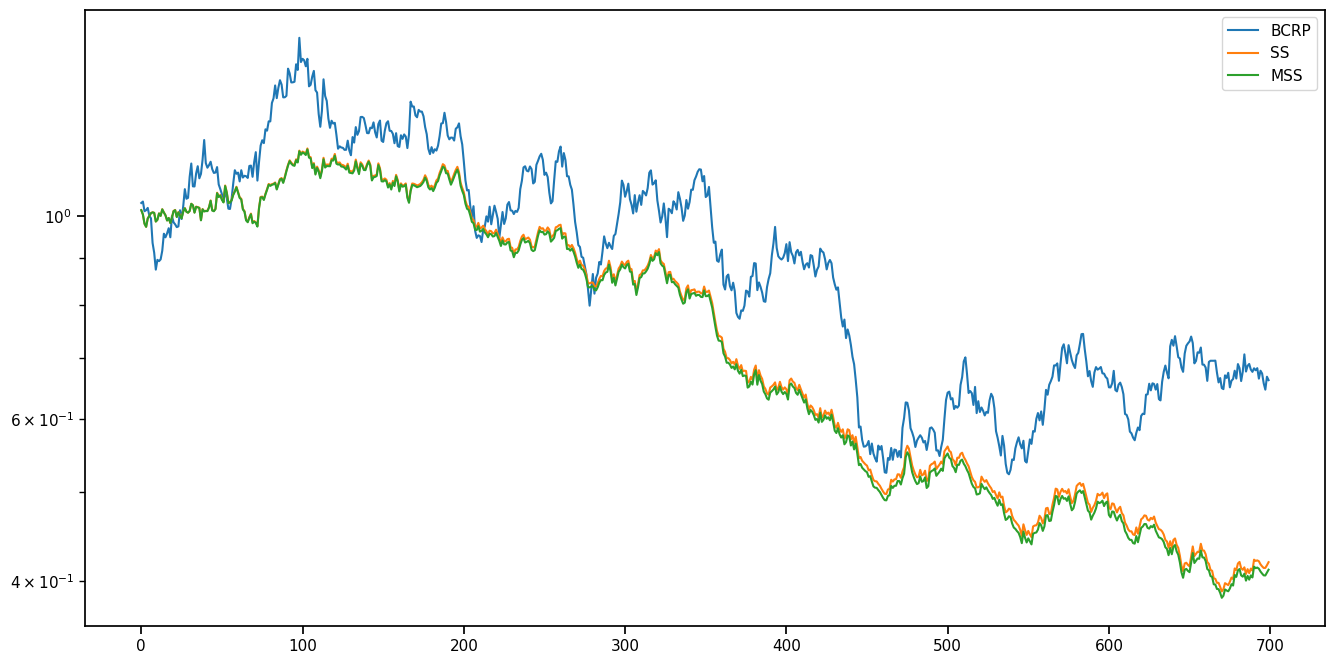

In [9]:
# cмотрим как ведут себя стратегии smooth и modified smooth по отношению к лучшей (в терминах OCO) стратегии
df[["BCRP", "SS", "MSS"]].plot(logy=True)

ПРОВЕРКА РАБОТЫ НА РЕАЛЬНЫХ ДАННЫХ

In [10]:
# выбор рассматриваемого периода
start = "2023-04-10"
end = "2025-04-10"

# выбор стоков
assets = ["JPM", "NFLX", "XOM", "VZ", "META"]
assets.sort()
n = len(assets)


# загрузка данных
data = yf.download(assets, start=start, end=end)
data = data.loc[:, ("Close", slice(None))]
data.columns = assets

# вычислениу r

df = 1 + data[assets].pct_change().dropna() / 100
r = df.to_numpy()
df = df.cumprod(axis=0)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed


<Axes: xlabel='Date'>

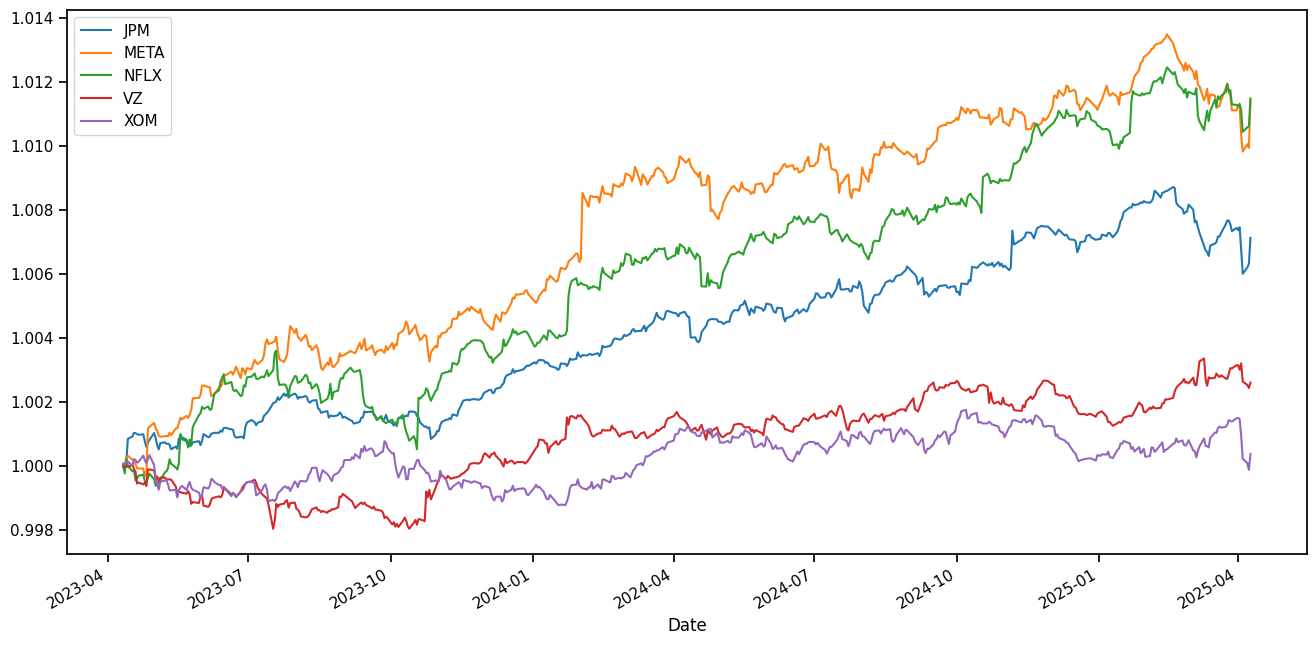

In [11]:
# cмотрим на траектории отдельных акций
df.plot()

In [12]:
ss = Smooth_Selection(r)
df["SS"] = np.cumprod(np.sum(r * ss, axis=1))

mss = Modified_Smooth_Selection(r)
df["ModifiedSS"] = np.cumprod(np.sum(r * mss, axis=1))

/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Axes: xlabel='Date'>

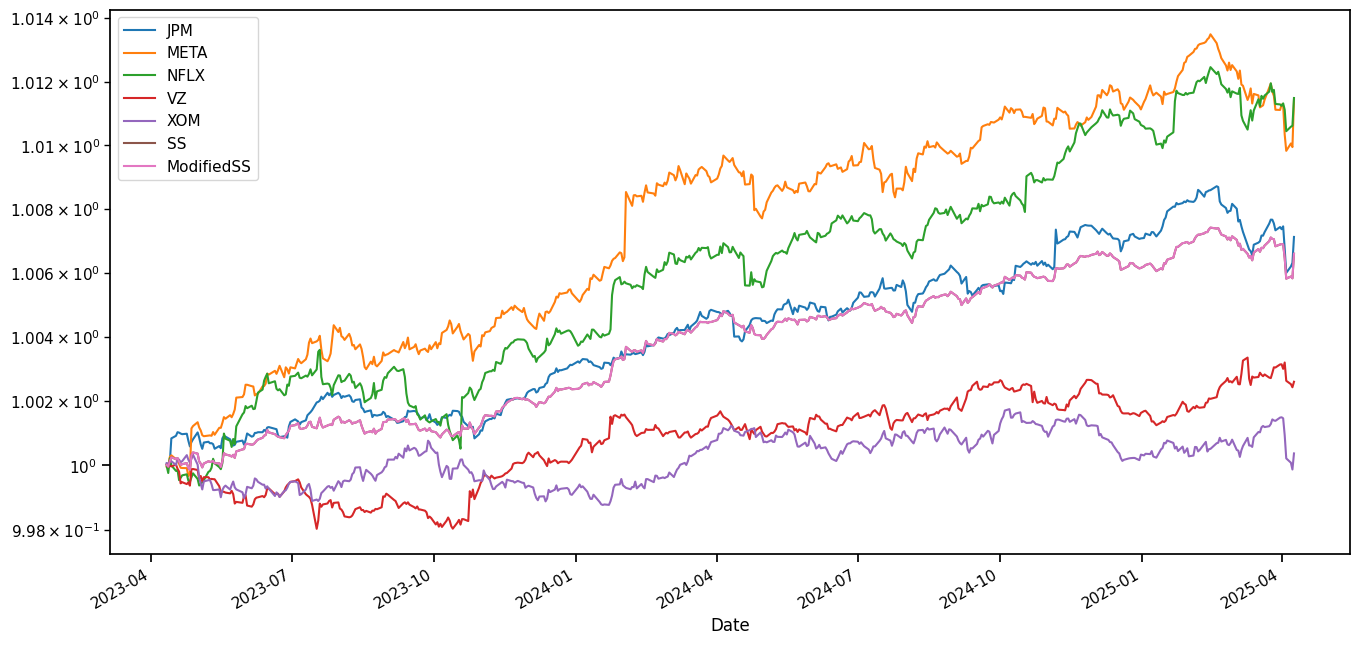

In [13]:
# cмотрим как ведут себя стратегии smooth и modified smooth по отношению к траекториям отдельных акций
df.plot(logy=True)

<Axes: xlabel='Date'>

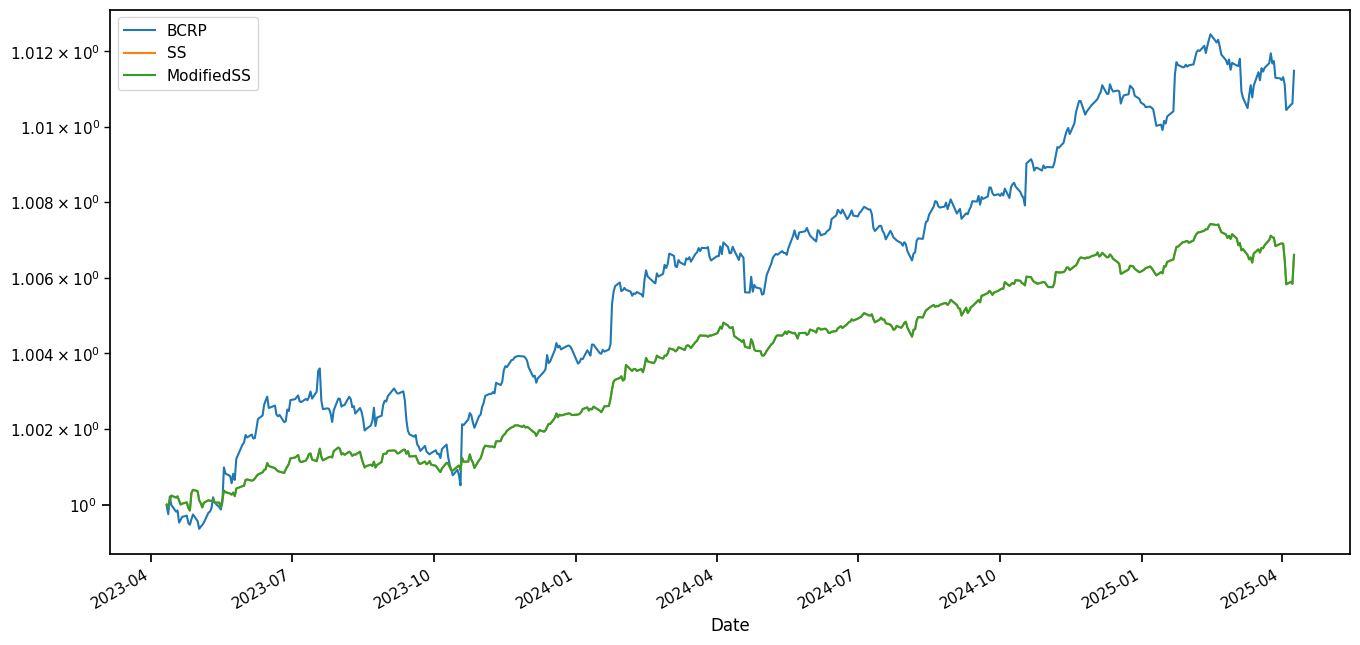

In [14]:
# cмотрим как ведут себя стратегии smooth и modified smooth по отношению к лучшей (в терминах OCO) стратегии

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)

df[["BCRP", "SS", "ModifiedSS"]].plot(logy=True)

В семинаре, в стратегии Linearized Follow-The--Leader, мы использовали линейную аппроксимацию:
**Linearizing** $$f_t(x) \sim f_t(x_t) + \nabla f_t(x_t)^T(x-x_t)$$

**А что если рассмотрим точность до второго порядка? -> т.е метод Ньютона.**
$$f_t(x) \sim f_t(x_t) + \nabla f_t(x_t)^T(x-x_t) + \frac{1}{2} (x-x_t)^TA_t(x_t)(x-x_t)$$

Здесь: $$A_t(x) = \frac{r_r r_t^T}{r_t^T x}$$
**Ну и выбор портфеля делаем:** $$x_{t+1} = argmin_{x\in \Delta_n} \sum_{t=1}^t f_t(x)$$

Тогда стратегия называется **Quadratized Follow-The-Leader**

Ну еще регуляризатор добавим: $$x_{t+1} = argmin_{x\in \Delta_n} \sum_{t=1}^t f_t(x) + \varepsilon R(x)$$ и получим **Quadratized Follow-The-Regularized-Leader**)).

 Здесь $\varepsilon$, чтобы общий случай рассмотреть: 0, если не учитываем регуляризатор и, например, 1, если учитываем.

Рассмотрим **регуляризатор** для квадратичных функций: $R(x) = \frac{1}{2} ||x||_2^2$








In [17]:
def Quadratized_Follow_The_Regularized_Leader(r, epsilon):
    T = r.shape[0]
    n = r.shape[1]
    xs = np.zeros((T, n))
    xs[0] = np.ones(n) / n

    for t in range(1, T):
        x = cp.Variable(n)

        objective = 0
        if epsilon > 0:
            objective = epsilon * 0.5 * cp.norm(x, 2) ** 2
        for i in range(t):
            grad = -r[i] / np.inner(r[i], xs[i])
            hess = np.outer(r[i], r[i]) / np.inner(r[i], xs[i])

            objective += (x - xs[i]) @ grad + 0.5 * cp.quad_form(
                x - xs[i], hess, assume_PSD=True
            )

        problem = cp.Problem(cp.Minimize(objective), [cp.sum(x) == 1, x >= 0])
        problem.solve()
        xs[t] = x.value

    return xs

In [18]:
qftl = Quadratized_Follow_The_Regularized_Leader(r, epsilon=0)
df["QFTL"] = np.cumprod(np.sum(r * qftl, axis=1))

qftrl = Quadratized_Follow_The_Regularized_Leader(r, epsilon=1)
df["QFTRL"] = np.cumprod(np.sum(r * qftrl, axis=1))

ss = Smooth_Selection(r)
df["SS"] = np.cumprod(np.sum(r * ss, axis=1))

mss = Modified_Smooth_Selection(r)
df["ModifiedSS"] = np.cumprod(np.sum(r * mss, axis=1))

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)

/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


<Axes: xlabel='Date'>

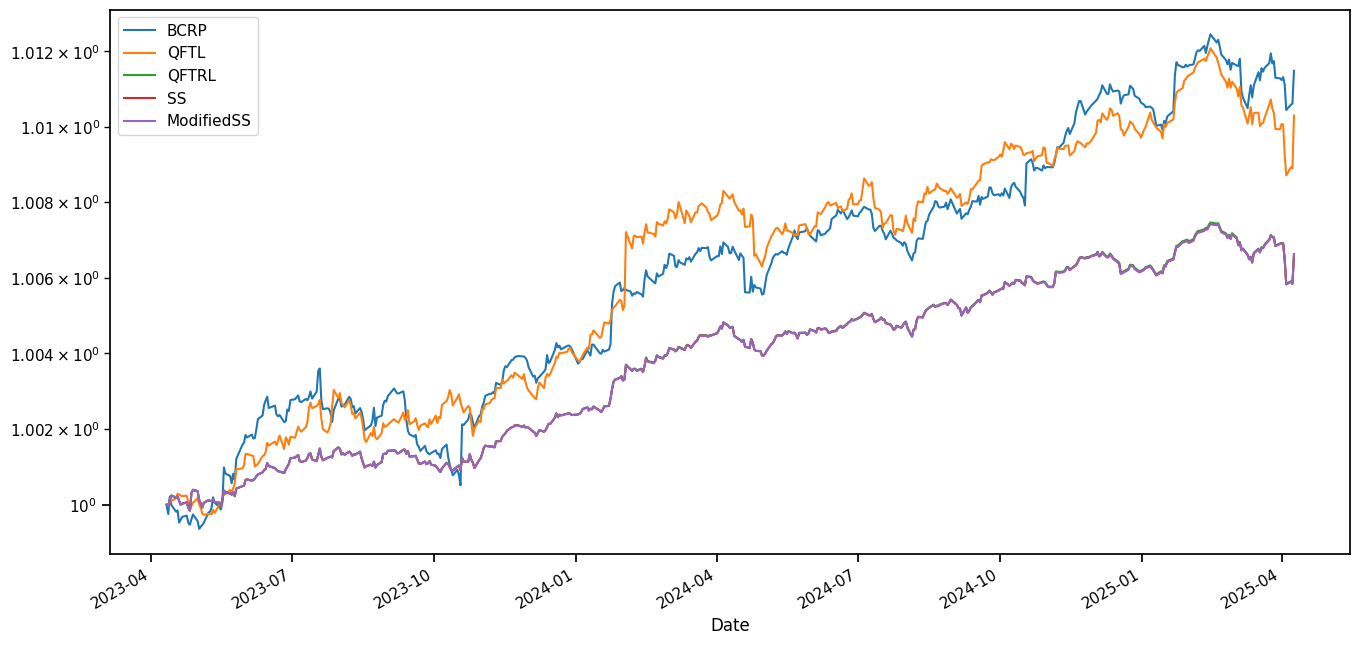

In [20]:
# cмотрим как ведут себя стратегии smooth, modified smooth, ftql на реальных данных  по отношению к лучшей (в терминах OCO) стратегии

df[["BCRP", "QFTL", "QFTRL", "SS", "ModifiedSS"]].plot(logy=True)

НА СИНТЕТИКЕ

In [21]:
random.seed(444)
np.random.seed(444)
# число стоков(акций)
n = 5
# генерим названия стоков
dummy_stocks = ["".join(random.choices(string.ascii_uppercase, k=5)) for i in range(n)]
# рассматриваемый период
T = 700

# Log-normal returns
r = np.exp(np.random.normal(0, 0.03, size=(T, n)))
df = pd.DataFrame(data=r.cumprod(axis=0), columns=dummy_stocks)

In [22]:
ss = Smooth_Selection(r)
df["SS"] = np.cumprod(np.sum(r * ss, axis=1))

mss = Modified_Smooth_Selection(r)
df["ModifiedSS"] = np.cumprod(np.sum(r * mss, axis=1))

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)

qftl = Quadratized_Follow_The_Regularized_Leader(r, epsilon=0)
df["QFTL"] = np.cumprod(np.sum(r * qftl, axis=1))

qftrl = Quadratized_Follow_The_Regularized_Leader(r, epsilon=1)
df["QFTRL"] = np.cumprod(np.sum(r * qftrl, axis=1))


/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "
/home/v1adych/micromamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too m

<Axes: >

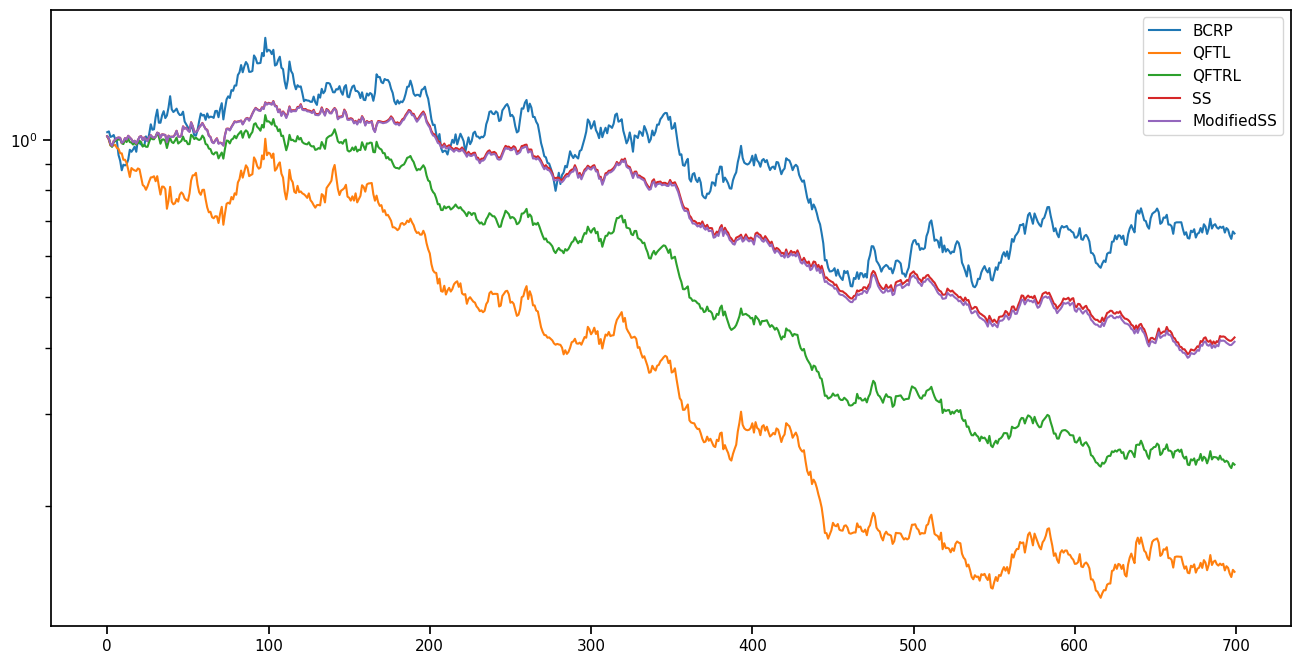

In [23]:
# cмотрим как ведут себя стратегии smooth, modified smooth, ftql по отношению к best (в терминах OCO) стратегии
df[["BCRP", "QFTL", "QFTRL", "SS", "ModifiedSS"]].plot(logy=True)

<Axes: >

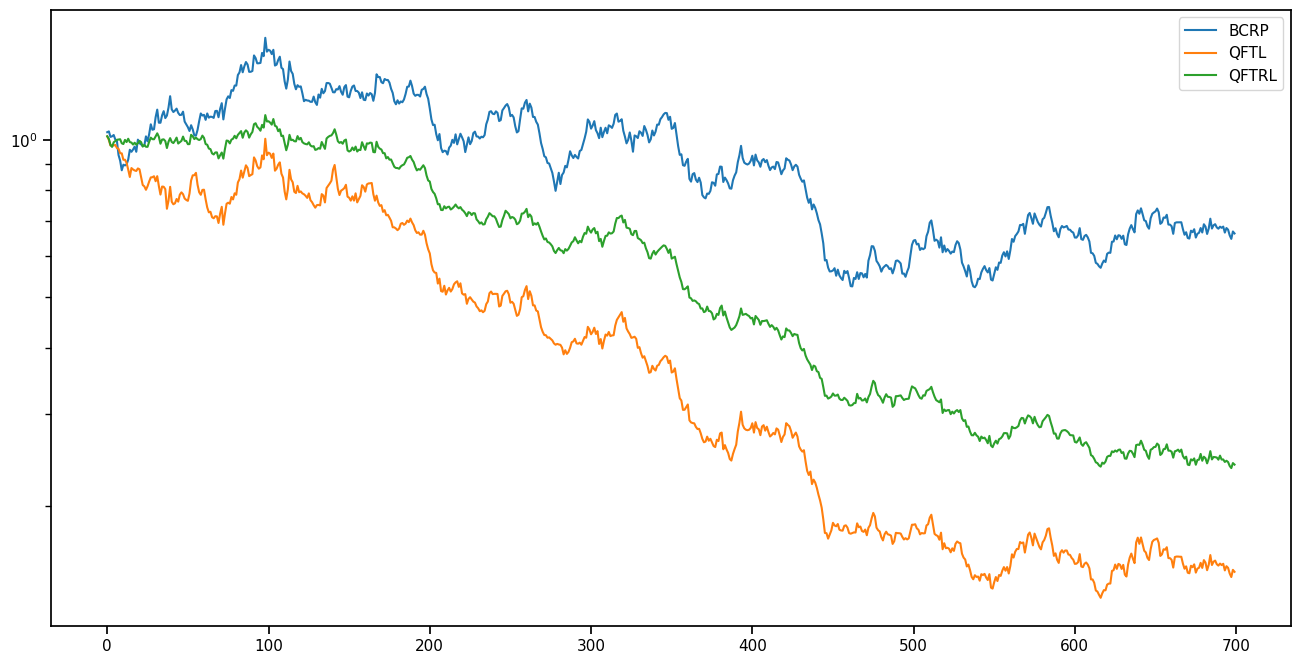

In [24]:
df[["BCRP", "QFTL", "QFTRL"]].plot(logy=True)